In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import f1_score, multilabel_confusion_matrix, roc_auc_score
from sklearn.preprocessing import MultiLabelBinarizer

from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, Add, MaxPooling1D,
    GlobalAveragePooling1D, Dense, Dropout, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [2]:
BASE_DIR = Path.cwd()
if not (BASE_DIR / "X_train_processed.npy").exists():
    BASE_DIR = Path(r"D:\AOU-Graduation-Project\BioIntellect\AI\ECG\App\classification")

TRAIN_AUDIO_PATH = BASE_DIR / "X_train_processed.npy"
VAL_AUDIO_PATH = BASE_DIR / "X_val_processed.npy"
TEST_AUDIO_PATH = BASE_DIR / "X_test_processed.npy"

TRAIN_CSV_PATH = BASE_DIR / "ptbxl_train.csv"
VAL_CSV_PATH = BASE_DIR / "ptbxl_val.csv"
TEST_CSV_PATH = BASE_DIR / "ptbxl_test.csv"

CSV_FEATURE_COLUMNS = [
    "age",
    "sex",
    "height",
    "weight",
    "validated_by_human",
    "height_missing",
    "weight_missing",
]

EXPECTED_SIGNAL_SHAPE = (5000, 12)
BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 3e-4
METRIC_THRESHOLD = 0.5

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

policy_name = "mixed_float16" if gpus else "float32"
mixed_precision.set_global_policy(policy_name)


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU, compute capability 8.6


In [3]:
def load_signal_npy(npy_path, mmap_mode="r"):
    signals = np.load(npy_path, allow_pickle=False, mmap_mode=mmap_mode)

    if signals.dtype != np.float32:
        signals = signals.astype(np.float32)

    if signals.ndim != 3 or tuple(signals.shape[1:]) != EXPECTED_SIGNAL_SHAPE:
        raise ValueError(
            f"Expected shape (N, {EXPECTED_SIGNAL_SHAPE[0]}, {EXPECTED_SIGNAL_SHAPE[1]}), got {signals.shape}"
        )

    return signals


def extract_codes_list(df):
    return df["scp_codes"].apply(lambda value: sorted(ast.literal_eval(value).keys()))


def build_feature_matrix(df, feature_cols):
    features = df[feature_cols].copy()

    bool_cols = features.select_dtypes(include=["bool"]).columns
    if len(bool_cols):
        features[bool_cols] = features[bool_cols].astype(np.float32)

    return features.astype(np.float32).to_numpy()


def assert_split_alignment(signals, features, labels, split_name):
    if len(signals) != len(features):
        raise ValueError(
            f"{split_name}: signals/features mismatch -> {len(signals)} vs {len(features)}"
        )

    if labels is not None and len(labels) != len(signals):
        raise ValueError(
            f"{split_name}: labels/signals mismatch -> {len(labels)} vs {len(signals)}"
        )


In [4]:
def bottleneck_block_1d(x, filters, stride=1, projection=False, name=None):
    shortcut = x
    out_channels = filters * 4

    if projection or stride != 1 or x.shape[-1] != out_channels:
        shortcut = Conv1D(
            out_channels, kernel_size=1, strides=stride,
            padding="same", use_bias=False, name=f"{name}_0_conv"
        )(shortcut)
        shortcut = BatchNormalization(name=f"{name}_0_bn")(shortcut)

    x = Conv1D(
        filters, kernel_size=1, strides=1,
        padding="same", use_bias=False, name=f"{name}_1_conv"
    )(x)
    x = BatchNormalization(name=f"{name}_1_bn")(x)
    x = ReLU(name=f"{name}_1_relu")(x)

    x = Conv1D(
        filters, kernel_size=3, strides=stride,
        padding="same", use_bias=False, name=f"{name}_2_conv"
    )(x)
    x = BatchNormalization(name=f"{name}_2_bn")(x)
    x = ReLU(name=f"{name}_2_relu")(x)

    x = Conv1D(
        out_channels, kernel_size=1, strides=1,
        padding="same", use_bias=False, name=f"{name}_3_conv"
    )(x)
    x = BatchNormalization(name=f"{name}_3_bn")(x)

    x = Add(name=f"{name}_add")([x, shortcut])
    x = ReLU(name=f"{name}_out")(x)

    return x


def make_stage(x, filters, blocks, first_stride, stage_name):
    x = bottleneck_block_1d(
        x, filters=filters, stride=first_stride,
        projection=True, name=f"{stage_name}_block1")

    for i in range(2, blocks + 1):
        x = bottleneck_block_1d(
            x, filters=filters, stride=1,
            projection=False, name=f"{stage_name}_block{i}")

    return x


def build_resnet1d50_backbone(signal_shape):
    signal_input = Input(shape=signal_shape, dtype=tf.float32, name="ecg_signal")

    x = Conv1D(64, kernel_size=7, strides=2, padding="same", use_bias=False, name="conv1")(signal_input)
    x = BatchNormalization(name="conv1_bn")(x)
    x = ReLU(name="conv1_relu")(x)
    x = MaxPooling1D(pool_size=3, strides=2, padding="same", name="pool1")(x)

    x = make_stage(x, filters=64, blocks=3, first_stride=1, stage_name="conv2")
    x = make_stage(x, filters=128, blocks=4, first_stride=2, stage_name="conv3")
    x = make_stage(x, filters=256, blocks=6, first_stride=2, stage_name="conv4")
    x = make_stage(x, filters=512, blocks=3, first_stride=2, stage_name="conv5")

    x = GlobalAveragePooling1D(name="avg_pool")(x)

    return Model(signal_input, x, name="ResNet1D50_Backbone")


In [5]:
def build_multimodal_resnet1d_model(signal_shape, num_csv_features, num_classes, learning_rate=LEARNING_RATE):
    signal_input = Input(shape=signal_shape, dtype=tf.float32, name="signal_input")
    csv_input = Input(shape=(num_csv_features,), dtype=tf.float32, name="csv_input")

    signal_backbone = build_resnet1d50_backbone(signal_shape)
    signal_features = signal_backbone(signal_input)

    csv_features = Dense(64, activation="relu", dtype="float32", name="csv_dense1")(csv_input)
    csv_features = Dropout(0.15, name="csv_dropout1")(csv_features)
    csv_features = Dense(32, activation="relu", dtype="float32", name="csv_dense2")(csv_features)

    merged = Concatenate(name="fusion")([signal_features, csv_features])

    x = Dense(512, activation="relu", dtype="float32", name="head_dense1")(merged)
    x = Dropout(0.20, name="head_dropout1")(x)
    x = Dense(256, activation="relu", dtype="float32", name="head_dense2")(x)
    x = Dropout(0.10, name="head_dropout2")(x)

    output = Dense(num_classes, activation="sigmoid", dtype="float32", name="output")(x)

    model = Model(inputs=[signal_input, csv_input], outputs=output, name="ECG_CSV_ResNet1D50")

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
            tf.keras.metrics.AUC(name="auc", multi_label=True),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model


In [6]:
def summarize_history(history):
    history_df = pd.DataFrame(history.history)
    print("Last epoch metrics:")
    print(history_df.tail(1).round(4).to_string(index=False))

    if "val_auc" in history_df.columns:
        best_epoch = int(history_df["val_auc"].idxmax()) + 1
        best_val_auc = float(history_df["val_auc"].max())
        print(f"Best validation AUC epoch: {best_epoch}")
        print(f"Best validation AUC: {best_val_auc:.4f}")

    return history_df


def plot_history(history_df):
    if history_df.empty:
        print("No history to plot.")
        return None

    epochs = range(1, len(history_df) + 1)
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    if "loss" in history_df.columns:
        axes[0].plot(epochs, history_df["loss"], marker="o", label="loss")
    if "val_loss" in history_df.columns:
        axes[0].plot(epochs, history_df["val_loss"], marker="o", label="val_loss")
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if "binary_accuracy" in history_df.columns:
        axes[1].plot(epochs, history_df["binary_accuracy"], marker="o", label="binary_accuracy")
    if "val_binary_accuracy" in history_df.columns:
        axes[1].plot(epochs, history_df["val_binary_accuracy"], marker="o", label="val_binary_accuracy")
    axes[1].set_title("Binary Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    if "auc" in history_df.columns:
        axes[2].plot(epochs, history_df["auc"], marker="o", label="auc")
    if "val_auc" in history_df.columns:
        axes[2].plot(epochs, history_df["val_auc"], marker="o", label="val_auc")
    axes[2].set_title("AUC")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig


def safe_multilabel_auc(y_true, y_score, average):
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    valid_columns = []
    for i in range(y_true.shape[1]):
        positive_count = y_true[:, i].sum()
        if 0 < positive_count < len(y_true):
            valid_columns.append(i)

    if not valid_columns:
        return np.nan

    return float(roc_auc_score(y_true[:, valid_columns], y_score[:, valid_columns], average=average))


def batched_multimodal_predict(model, x_signal, x_csv, batch_size=BATCH_SIZE):
    if len(x_signal) != len(x_csv):
        raise ValueError(f"signals/features mismatch -> {len(x_signal)} vs {len(x_csv)}")

    predictions = []
    for start in range(0, len(x_signal), batch_size):
        end = min(start + batch_size, len(x_signal))
        signal_batch = np.array(x_signal[start:end], dtype=np.float32)
        csv_batch = np.array(x_csv[start:end], dtype=np.float32)
        batch_prediction = model([signal_batch, csv_batch], training=False).numpy()
        predictions.append(batch_prediction)

    if not predictions:
        return np.empty((0, model.output_shape[-1]), dtype=np.float32)

    return np.vstack(predictions).astype(np.float32)


def show_multilabel_confusion_matrices(y_true, y_pred, class_names, top_k=9, label_indices=None):
    y_true = np.array(y_true, dtype=np.int32)
    y_pred = np.array(y_pred, dtype=np.int32)
    matrices = multilabel_confusion_matrix(y_true, y_pred)
    support = y_true.sum(axis=0)

    if label_indices is None:
        label_indices = np.argsort(-support)[:top_k]

    label_indices = list(label_indices)
    if not label_indices:
        return {}

    cols = min(3, len(label_indices))
    rows = int(np.ceil(len(label_indices) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    results = {}
    for plot_index, idx in enumerate(label_indices):
        label_name = str(class_names[idx])
        table = pd.DataFrame(
            matrices[idx],
            index=["Actual 0", "Actual 1"],
            columns=["Pred 0", "Pred 1"],
        )
        sns.heatmap(table, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[plot_index])
        axes[plot_index].set_title(f"{label_name} (support={int(support[idx])})")
        results[label_name] = table

    for i in range(len(label_indices), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

    return results


def evaluate_multimodal_split(model, x_signal, x_csv, y_true, split_name, threshold=METRIC_THRESHOLD):
    y_score = batched_multimodal_predict(model, x_signal, x_csv, batch_size=BATCH_SIZE)
    y_pred = (y_score >= threshold).astype(np.float32)

    return {
        "split": split_name,
        "binary_accuracy": float((y_pred == y_true).mean()),
        "f1_micro": float(f1_score(y_true, y_pred, average="micro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "auc_micro": safe_multilabel_auc(y_true, y_score, average="micro"),
        "auc_macro": safe_multilabel_auc(y_true, y_score, average="macro"),
    }


In [7]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
val_df = pd.read_csv(VAL_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

X_train_signal = load_signal_npy(TRAIN_AUDIO_PATH)
X_val_signal = load_signal_npy(VAL_AUDIO_PATH)
X_test_signal = load_signal_npy(TEST_AUDIO_PATH)

X_train_csv = build_feature_matrix(train_df, CSV_FEATURE_COLUMNS)
X_val_csv = build_feature_matrix(val_df, CSV_FEATURE_COLUMNS)
X_test_csv = build_feature_matrix(test_df, CSV_FEATURE_COLUMNS)

mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(extract_codes_list(train_df)).astype(np.float32)
y_val = mlb.transform(extract_codes_list(val_df)).astype(np.float32)
y_test = mlb.transform(extract_codes_list(test_df)).astype(np.float32)

assert_split_alignment(X_train_signal, X_train_csv, y_train, "train")
assert_split_alignment(X_val_signal, X_val_csv, y_val, "val")
assert_split_alignment(X_test_signal, X_test_csv, y_test, "test")

SIGNAL_SHAPE = X_train_signal.shape[1:]
NUM_CLASSES = y_train.shape[1]

print("Train signal:", X_train_signal.shape, X_train_signal.dtype)
print("Val signal:", X_val_signal.shape, X_val_signal.dtype)
print("Test signal:", X_test_signal.shape, X_test_signal.dtype)
print("Train CSV:", X_train_csv.shape, X_train_csv.dtype)
print("Labels:", NUM_CLASSES)
print("classes:", mlb.classes_[:].tolist())


Train signal: (17418, 5000, 12) float32
Val signal: (2183, 5000, 12) float32
Test signal: (2198, 5000, 12) float32
Train CSV: (17418, 7) float32
Labels: 71
classes: ['1AVB', '2AVB', '3AVB', 'ABQRS', 'AFIB', 'AFLT', 'ALMI', 'AMI', 'ANEUR', 'ASMI', 'BIGU', 'CLBBB', 'CRBBB', 'DIG', 'EL', 'HVOLT', 'ILBBB', 'ILMI', 'IMI', 'INJAL', 'INJAS', 'INJIL', 'INJIN', 'INJLA', 'INVT', 'IPLMI', 'IPMI', 'IRBBB', 'ISCAL', 'ISCAN', 'ISCAS', 'ISCIL', 'ISCIN', 'ISCLA', 'ISC_', 'IVCD', 'LAFB', 'LAO/LAE', 'LMI', 'LNGQT', 'LOWT', 'LPFB', 'LPR', 'LVH', 'LVOLT', 'NDT', 'NORM', 'NST_', 'NT_', 'PAC', 'PACE', 'PMI', 'PRC(S)', 'PSVT', 'PVC', 'QWAVE', 'RAO/RAE', 'RVH', 'SARRH', 'SBRAD', 'SEHYP', 'SR', 'STACH', 'STD_', 'STE_', 'SVARR', 'SVTAC', 'TAB_', 'TRIGU', 'VCLVH', 'WPW']


In [8]:
model = build_multimodal_resnet1d_model(
    signal_shape=SIGNAL_SHAPE,
    num_csv_features=X_train_csv.shape[1],
    num_classes=NUM_CLASSES,
)

model.summary()

Model: "ECG_CSV_ResNet1D50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 csv_input (InputLayer)         [(None, 7)]          0           []                               
                                                                                                  
 csv_dense1 (Dense)             (None, 64)           512         ['csv_input[0][0]']              
                                                                                                  
 signal_input (InputLayer)      [(None, 5000, 12)]   0           []                               
                                                                                                  
 csv_dropout1 (Dropout)         (None, 64)           0           ['csv_dense1[0][0]']             
                                                                                 

In [9]:
callbacks = [
    ModelCheckpoint(
        BASE_DIR / "resnet1d50_multimodal_best.weights.h5",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1,
    ),
]

In [10]:
history = model.fit(
    [X_train_signal, X_train_csv],
    y_train,
    validation_data=([X_val_signal, X_val_csv], y_val),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)



Epoch 1/100
2178/2178 [==============================] - ETA: 0s - loss: 0.0967 - binary_accuracy: 0.9709 - auc: 0.6817 - precision: 0.7248 - recall: 0.4225
Epoch 1: val_auc improved from -inf to 0.76700, saving model to d:\AOU-Graduation-Project\BioIntellect\AI\ECG\App\classification\resnet1d50_multimodal_best.weights.h5
2178/2178 [==============================] - 220s 92ms/step - loss: 0.0967 - binary_accuracy: 0.9709 - auc: 0.6817 - precision: 0.7248 - recall: 0.4225 - val_loss: 0.0851 - val_binary_accuracy: 0.9730 - val_auc: 0.7670 - val_precision: 0.7578 - val_recall: 0.4597 - lr: 3.0000e-04
Epoch 2/100
2178/2178 [==============================] - ETA: 0s - loss: 0.0796 - binary_accuracy: 0.9749 - auc: 0.7652 - precision: 0.7835 - recall: 0.5023
Epoch 2: val_auc improved from 0.76700 to 0.78121, saving model to d:\AOU-Graduation-Project\BioIntellect\AI\ECG\App\classification\resnet1d50_multimodal_best.weights.h5
2178/2178 [==============================] - 198s 91ms/step - loss: 

Last epoch metrics:
  loss  binary_accuracy   auc  precision  recall  val_loss  val_binary_accuracy  val_auc  val_precision  val_recall     lr
0.0528           0.9817 0.906     0.8381  0.6642    0.0621               0.9789   0.8849         0.7828      0.6387 0.0003
Best validation AUC epoch: 11
Best validation AUC: 0.8868


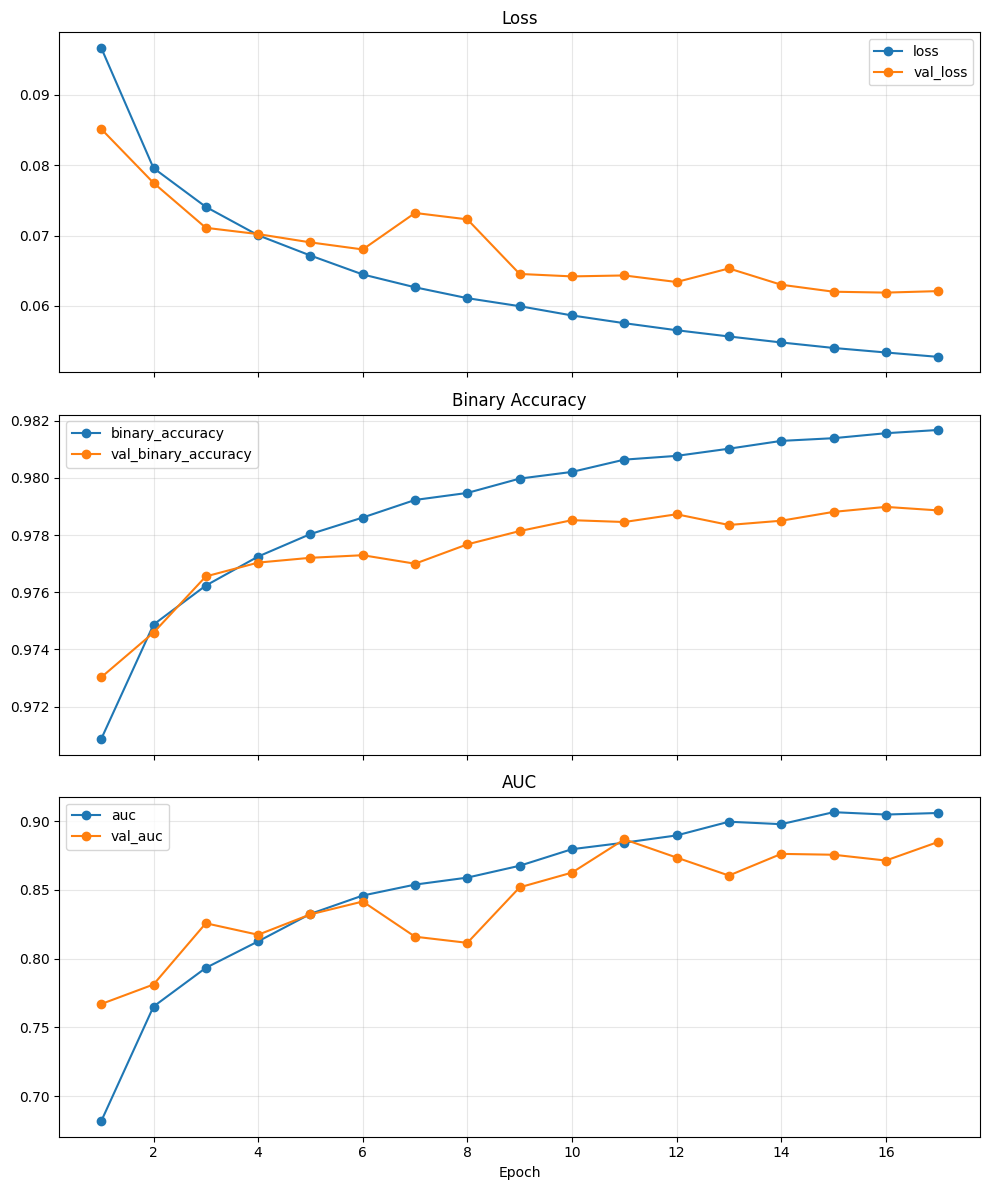

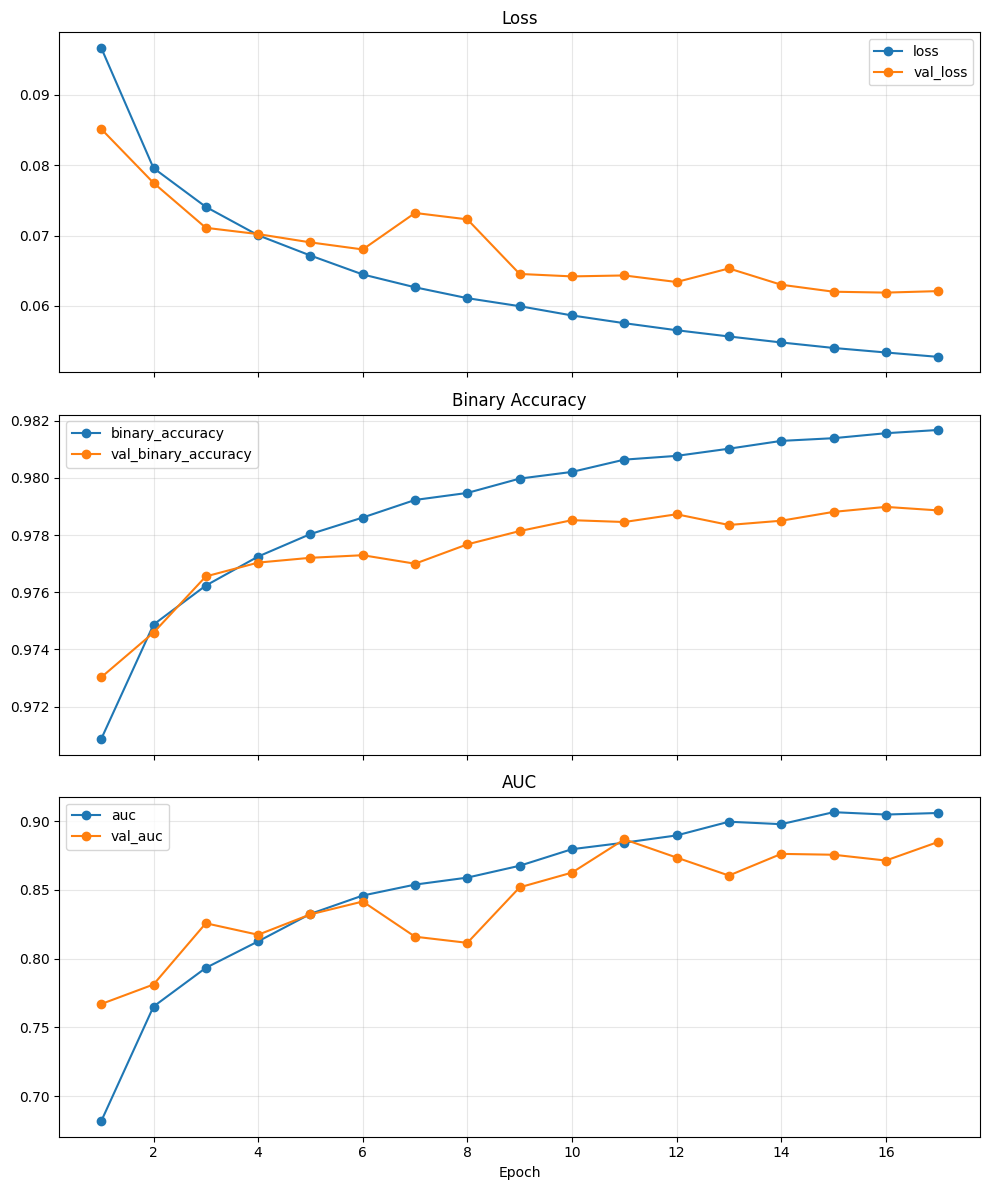

In [11]:
history_df = summarize_history(history)
plot_history(history_df)

In [12]:
split_metrics = [
    evaluate_multimodal_split(model, X_train_signal, X_train_csv, y_train, "train"),
    evaluate_multimodal_split(model, X_val_signal, X_val_csv, y_val, "validation"),
    evaluate_multimodal_split(model, X_test_signal, X_test_csv, y_test, "test"),
]

metrics_df = pd.DataFrame(split_metrics).set_index("split").round(4)
print("Final evaluation metrics:")
print(metrics_df.to_string())
metrics_df


Final evaluation metrics:
            binary_accuracy  f1_micro  f1_macro  auc_micro  auc_macro
split                                                                
train                0.9815    0.7438    0.2663     0.9831     0.9492
validation           0.9785    0.6979    0.2135     0.9725     0.9126
test                 0.9781    0.6934    0.2229     0.9721     0.9023


,binary_accuracy,f1_micro,f1_macro,auc_micro,auc_macro
split,,,,,
train,0.9815,0.7438,0.2663,0.9831,0.9492
validation,0.9785,0.6979,0.2135,0.9725,0.9126
test,0.9781,0.6934,0.2229,0.9721,0.9023


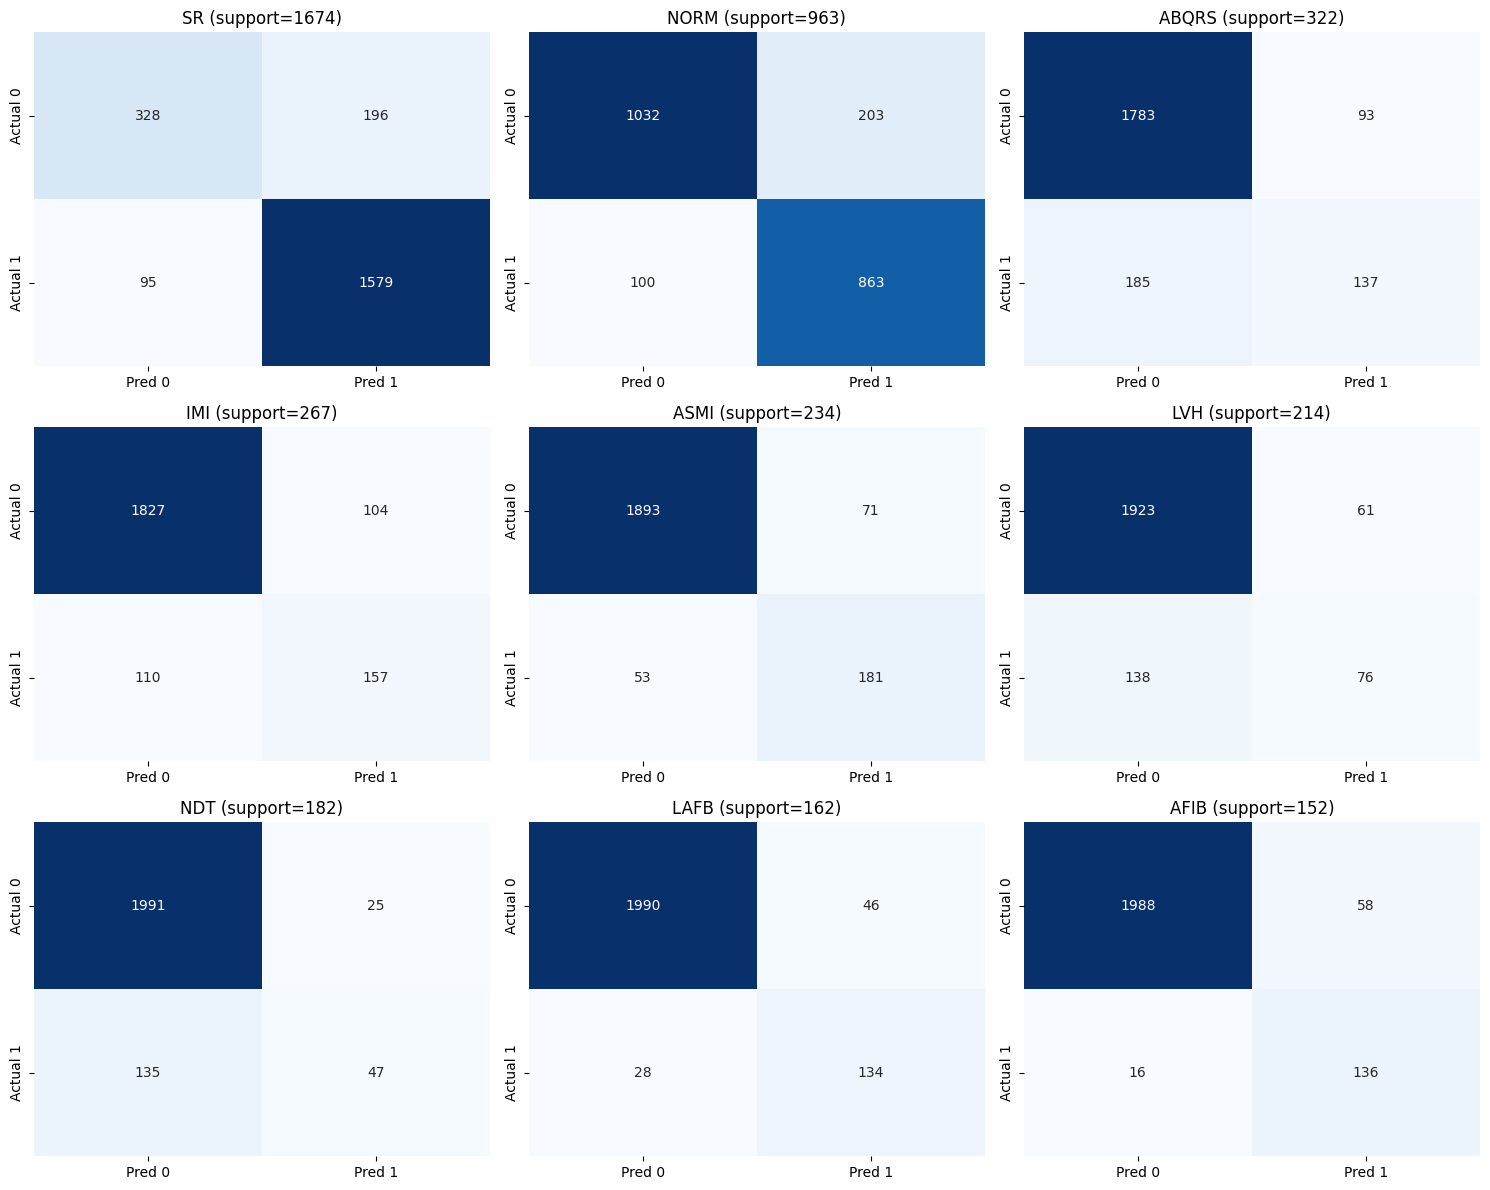

{'SR':           Pred 0  Pred 1
 Actual 0     328     196
 Actual 1      95    1579,
 'NORM':           Pred 0  Pred 1
 Actual 0    1032     203
 Actual 1     100     863,
 'ABQRS':           Pred 0  Pred 1
 Actual 0    1783      93
 Actual 1     185     137,
 'IMI':           Pred 0  Pred 1
 Actual 0    1827     104
 Actual 1     110     157,
 'ASMI':           Pred 0  Pred 1
 Actual 0    1893      71
 Actual 1      53     181,
 'LVH':           Pred 0  Pred 1
 Actual 0    1923      61
 Actual 1     138      76,
 'NDT':           Pred 0  Pred 1
 Actual 0    1991      25
 Actual 1     135      47,
 'LAFB':           Pred 0  Pred 1
 Actual 0    1990      46
 Actual 1      28     134,
 'AFIB':           Pred 0  Pred 1
 Actual 0    1988      58
 Actual 1      16     136}

In [13]:
test_score = batched_multimodal_predict(model, X_test_signal, X_test_csv, batch_size=BATCH_SIZE)
test_pred = (test_score >= METRIC_THRESHOLD).astype(np.int32)

test_confusion_matrices = show_multilabel_confusion_matrices(y_test, test_pred, mlb.classes_, top_k=9)
test_confusion_matrices
